# **다중 선형 회귀 분석 모델 학습**

housing.csv 파일을 여기에 업로드하고 프로그램하세요.

참고싸이트: https://github.com/wikibook/math_dl_book_info/blob/master/notebooks/ch07-regression.ipynb

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 데이터 로드
data = np.genfromtxt('housing.csv')

# 다음 코드를 잘 숙지하시오.
x = data[:, [5,12]] # 6번째 RM, 13번째 LSTAT
x = np.insert(x, 0, 1.0, axis=1)

# 다음에 yt 변수를 셋팅하는 코드를 넣으시오
yt = data[:, 13]  # 14번째 변수 (PRICE)

print(x.shape)
print(yt.shape)

(506, 3)
(506,)


In [3]:
print(x[:5])
print(yt[:5])

[[1.    6.575 4.98 ]
 [1.    6.421 9.14 ]
 [1.    7.185 4.03 ]
 [1.    6.998 2.94 ]
 [1.    7.147 5.33 ]]
[24.  21.6 34.7 33.4 36.2]


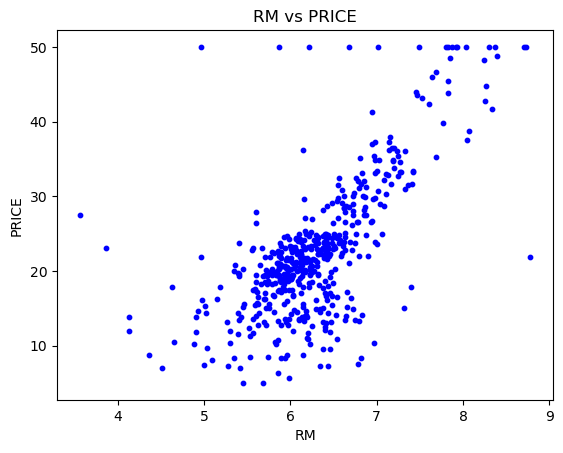

In [4]:
# ROOM-PRICE 산점도를 표시(X축은 RM, Y축은 PRICE)
plt.scatter(x[:, 1], yt, s=10, c='b')
plt.xlabel('RM')
plt.ylabel('PRICE')
plt.title('RM vs PRICE')
plt.show()  

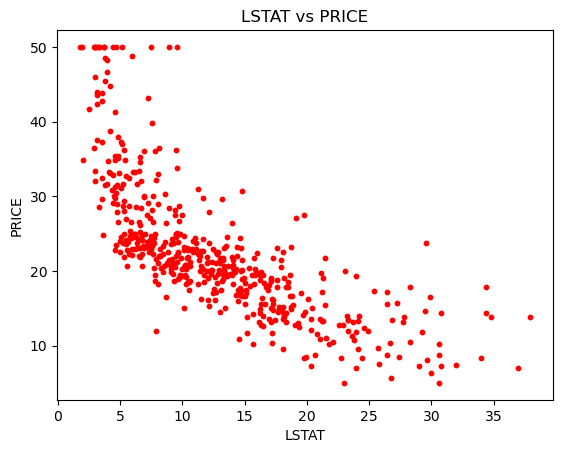

In [5]:
# LSTAT-PRICE 산점도를 표시(X축은 LSTAT, Y축은 PRICE)
plt.scatter(x[:, 2], yt, s=10, c='r')
plt.xlabel('LSTAT')
plt.ylabel('PRICE')
plt.title('LSTAT vs PRICE')
plt.show()

In [6]:
# 예측함수 정의: (1, x)의 값에서 예측값 yp를 계산
def pred(x, w):
    yp = np.dot(x, w)
    return yp

In [7]:
# 초기화(초기 설정)

M, D = x.shape
iters = 50000
alpha = 0.01

w = np.ones(D)
history = np.zeros((0,2))

print(M, D)
print(w)
print(history)

506 3
[1. 1. 1.]
[]


In [ ]:
# 반복 루프(경사하강법)
for k in range(iters):
    yp = pred(x, w)
    yd = yp - yt
    grad = np.dot(x.T, yd) / M
    w -= alpha * grad
    
    # 100번마다 학습 곡선 기록
    if k % 100 == 0:
        loss = np.mean(yd ** 2)
        history = np.vstack((history, [k, loss]))
        print(f"iter {k:4d}, Loss: {loss}") 

iter    0, Loss: 224.127963215415
iter  100, Loss: 7.507646973699219e+30
iter  200, Loss: 5.3106681801841e+60
iter  300, Loss: 3.756595990570894e+90
iter  400, Loss: 2.6572952701187235e+120
iter  500, Loss: 1.8796852710057433e+150
iter  600, Loss: 1.3296289493181215e+180
iter  700, Loss: 9.405367856709688e+209
iter  800, Loss: 6.653054941786064e+239
iter  900, Loss: 4.706157242626833e+269
iter 1000, Loss: 3.328984381779833e+299
iter 1100, Loss: inf
iter 1200, Loss: inf
iter 1300, Loss: inf
iter 1400, Loss: inf
iter 1500, Loss: inf
iter 1600, Loss: inf
iter 1700, Loss: inf
iter 1800, Loss: inf
iter 1900, Loss: inf
iter 2000, Loss: inf
iter 2100, Loss: nan
iter 2200, Loss: nan
iter 2300, Loss: nan
iter 2400, Loss: nan
iter 2500, Loss: nan
iter 2600, Loss: nan
iter 2700, Loss: nan
iter 2800, Loss: nan
iter 2900, Loss: nan
iter 3000, Loss: nan
iter 3100, Loss: nan
iter 3200, Loss: nan
iter 3300, Loss: nan
iter 3400, Loss: nan
iter 3500, Loss: nan
iter 3600, Loss: nan
iter 3700, Loss: nan
i

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28092\488301209.py:10: RuntimeWarning: overflow encountered in square
  loss = np.mean(yd ** 2)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28092\488301209.py:6: RuntimeWarning: invalid value encountered in subtract
  w -= alpha * grad


iter 25400, Loss: nan
iter 25500, Loss: nan
iter 25600, Loss: nan
iter 25700, Loss: nan
iter 25800, Loss: nan
iter 25900, Loss: nan
iter 26000, Loss: nan
iter 26100, Loss: nan
iter 26200, Loss: nan
iter 26300, Loss: nan
iter 26400, Loss: nan
iter 26500, Loss: nan
iter 26600, Loss: nan
iter 26700, Loss: nan
iter 26800, Loss: nan
iter 26900, Loss: nan
iter 27000, Loss: nan
iter 27100, Loss: nan
iter 27200, Loss: nan
iter 27300, Loss: nan
iter 27400, Loss: nan
iter 27500, Loss: nan
iter 27600, Loss: nan
iter 27700, Loss: nan
iter 27800, Loss: nan
iter 27900, Loss: nan
iter 28000, Loss: nan
iter 28100, Loss: nan
iter 28200, Loss: nan
iter 28300, Loss: nan
iter 28400, Loss: nan
iter 28500, Loss: nan
iter 28600, Loss: nan
iter 28700, Loss: nan
iter 28800, Loss: nan
iter 28900, Loss: nan
iter 29000, Loss: nan
iter 29100, Loss: nan
iter 29200, Loss: nan
iter 29300, Loss: nan
iter 29400, Loss: nan
iter 29500, Loss: nan
iter 29600, Loss: nan
iter 29700, Loss: nan
iter 29800, Loss: nan
iter 29900

In [11]:
# alpha = 0.01로 학습하니 발산하여, alpha = 0.001로 수정하여 학습

# 초기 설정
alpha = 0.001
iters = 2000
w = np.ones(D)
history = np.zeros((0,2))

In [12]:
# 반복 루프(경사하강법)
for k in range(iters):
    yp = pred(x, w)
    yd = yp - yt
    grad = np.dot(x.T, yd) / M
    w -= alpha * grad
    
    # 100번마다 학습 곡선 기록
    if k % 100 == 0:
        loss = np.mean(yd ** 2)/2
        history = np.vstack((history, [k, loss]))
        print(f"iter {k:4d}, Loss: {loss}") 

iter    0, Loss: 112.0639816077075
iter  100, Loss: 25.358934200838437
iter  200, Loss: 16.39105485058605
iter  300, Loss: 15.403015477091875
iter  400, Loss: 15.29413500663208
iter  500, Loss: 15.282113695594544
iter  600, Loss: 15.280763630069561
iter  700, Loss: 15.280589272586083
iter  800, Loss: 15.280544476062442
iter  900, Loss: 15.280513983829719
iter 1000, Loss: 15.28048509773749
iter 1100, Loss: 15.280456418763167
iter 1200, Loss: 15.28042779273731
iter 1300, Loss: 15.280399202639066
iter 1400, Loss: 15.280370646557646
iter 1500, Loss: 15.280342124247019
iter 1600, Loss: 15.28031363564459
iter 1700, Loss: 15.280285180708036
iter 1800, Loss: 15.280256759397291
iter 1900, Loss: 15.280228371672594


In [13]:
# 최종 손실함수 초깃값과 최종값 출력
print(f"손실함수 초깃값: {history[0, 1]}, 손실함수 최종값: {history[-1, 1]}")


손실함수 초깃값: 112.0639816077075, 손실함수 최종값: 15.280228371672594


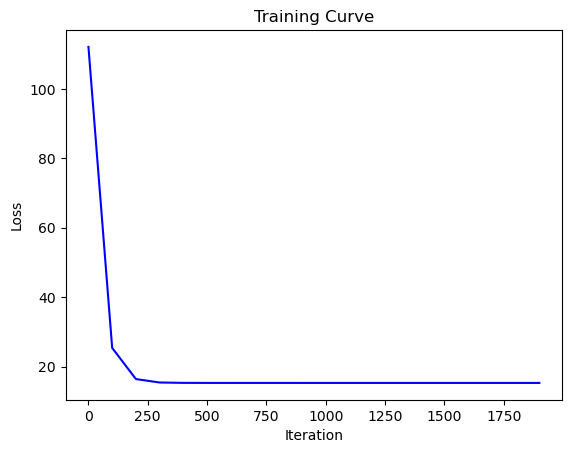

In [ ]:
# 학습곡선(손실) 출력
plt.plot(history[:, 0], history[:, 1], 'b-')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Training Curve(Loss)')
plt.show()


In [23]:
# 질문: 이 데이터를 학습해 얻은 모델 식을 적으시오.
print(f"모델 식: y = {w[0]:.4f} + {w[1]:.4f}*x1 {w[2]:.4f}*x2")


모델 식: y = 1.4621 + 4.7045*x1 -0.6701*x2


In [ ]:
# RM = 6.42, LSTAT = 9.14일 때 집 값을 예측하는 코드를 작성하시오. 얼마쯤인가?
y_pred = w[0] + w[1]*6.42 + w[2]*9.14
print(f"예측된 집 값: {y_pred:.4f}") # 소숫점 4자리까지 출력
print(f"예측된 집 값: {y_pred}")


예측된 집 값: 25.5403
예측된 집 값: 25.540334443939983
